# Análise de Dados do Nobeyama Radio Polarimeter (NoRP)

In [1]:
# Inicialização

from google.colab import drive
drive.mount('/content/drive')

exec(open("/content/drive/MyDrive/Bruno/norp_2002_05_31/norp.py").read())

import pandas as pd
import numpy as np
import astropy.io.fits as iofits

from google.colab import output
output.enable_custom_widget_manager()

#

import matplotlib
import matplotlib.pyplot as plt

%matplotlib widget

from datetime import datetime, timezone
from matplotlib.dates import num2date,DateFormatter

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Download do arquivo de dados do evento (formato FITS)

from IPython.display import HTML

url = "https://solar.nro.nao.ac.jp/norp/fits/"
HTML(f'<a href="{url}" target="_blank">Clique aqui para abrir a URL</a>')

In [3]:
# Seleção do arquivo de dados

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print('JST: ',norp_rd_obsDay(filename))
print('START TIME: ', norp_rd_sttim(filename))
print('END TIME: ', norp_rd_edtim(filename))

Saving norp020531.fits.gz to norp020531.fits (1).gz
JST:  2002-05-31
START TIME:  2002-05-30T21:00:00.064
END TIME:  2002-05-31T08:30:00.660


In [4]:
# Verificação das frequências para as quais existem dados da observação (0: não ; 1: sim)

print('FREQUÊNCIAS: ', norp_rd_existFreq(filename))

FREQUÊNCIAS:  {'1GHz': 1, '2GHz': 1, '3.75GHz': 1, '9.4GHz': 1, '17GHz': 1, '35GHz': 1, '80GHz': 1}


In [5]:
# Verificação da existência de valor máximo do fluxo para cada frequência (em caso de erro no gráfico)

print(max(norp_rd_1GHzI(filename)),max(norp_rd_2GHzI(filename)),max(norp_rd_4GHzI(filename)),max(norp_rd_9GHzI(filename)),max(norp_rd_17GHzI(filename)),max(norp_rd_35GHzI(filename)),max(norp_rd_80GHzI(filename)))

511.21152 208.52449 317.3859 684.2715 871.1799 2579.2979 9107.178


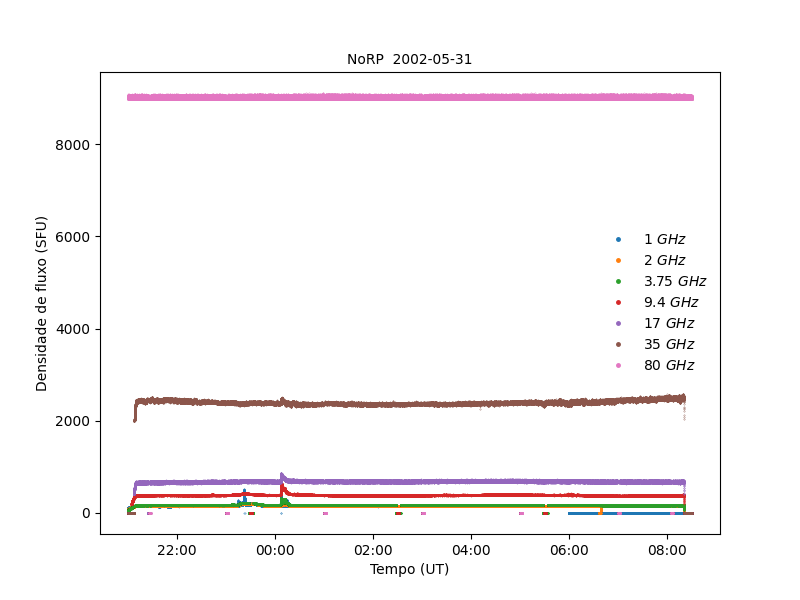

button_press_event: xy=(229, 515) xydata=(11837.960710979996, 9288.440386454266) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)
button_press_event: xy=(311, 84) xydata=(11837.998612437217, 203.5381542411062) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)
button_press_event: xy=(431, 80) xydata=(11838.020167768338, 121.69271382772513) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)


In [6]:
# Curvas de luz (perfis temporais)

lightcurve1 = plt.figure(figsize=(8, 6))
lightcurve1.canvas.mpl_connect('button_press_event', onclick)
lc1=lightcurve1.add_subplot()
plt.title('NoRP  '+norp_rd_obsDay(filename), fontsize=10)
plt.plot (norp_rd_time(filename)[:],norp_rd_1GHzI(filename)[:], marker=".", linestyle='None', markersize=0.5, label='$1~GHz$')
plt.plot (norp_rd_time(filename)[:],norp_rd_2GHzI(filename)[:], marker=".", linestyle='None', markersize=0.5, label='$2~GHz$')
plt.plot (norp_rd_time(filename)[:],norp_rd_4GHzI(filename)[:], marker=".", linestyle='None', markersize=0.5, label='$3.75~GHz$')
plt.plot (norp_rd_time(filename)[:],norp_rd_9GHzI(filename)[:], marker=".", linestyle='None', markersize=0.5, label='$9.4~GHz$')
plt.plot (norp_rd_time(filename)[:],norp_rd_17GHzI(filename)[:], marker=".", linestyle='None', markersize=0.5, label='$17~GHz$')
plt.plot (norp_rd_time(filename)[:],norp_rd_35GHzI(filename)[:], marker=".", linestyle='None', markersize=0.5, label='$35~GHz$')
plt.plot (norp_rd_time(filename)[:],norp_rd_80GHzI(filename)[:], marker=".", linestyle='None', markersize=0.5, label='$80~GHz$')
lc1.xaxis.set_major_formatter(DateFormatter('%H:%M'))
plt.xlabel('Tempo (UT)', fontsize=10)
plt.ylabel('Densidade de fluxo (SFU)', fontsize=10)
plt.legend(loc='best', markerscale=10, fontsize=10, frameon=False)

In [7]:
# Seleção do intervalo de tempo para análise
#
# obs - selecionar um intervalo de tempo incluindo instantes "pre-flare", "flare" e "post-flare"

tmin = posicao[-2]
tmax = posicao[-1]
#
pmin = num2date(tmin[0])
pmax = num2date(tmax[0])
#
# Determinação dos índices dos tempos inicial (tmin) e final (tmax)
#
tempos = pd.DataFrame(norp_rd_time(filename))
imin = np.argmin(np.abs(tempos - pmin))
imax = np.argmin(np.abs(tempos - pmax))

print('tmin=',norp_rd_time(filename)[imin].strftime('%H:%M:%S'))
print('tmax=',norp_rd_time(filename)[imax].strftime('%H:%M:%S'))

tmin= 23:58:00
tmax= 00:29:02


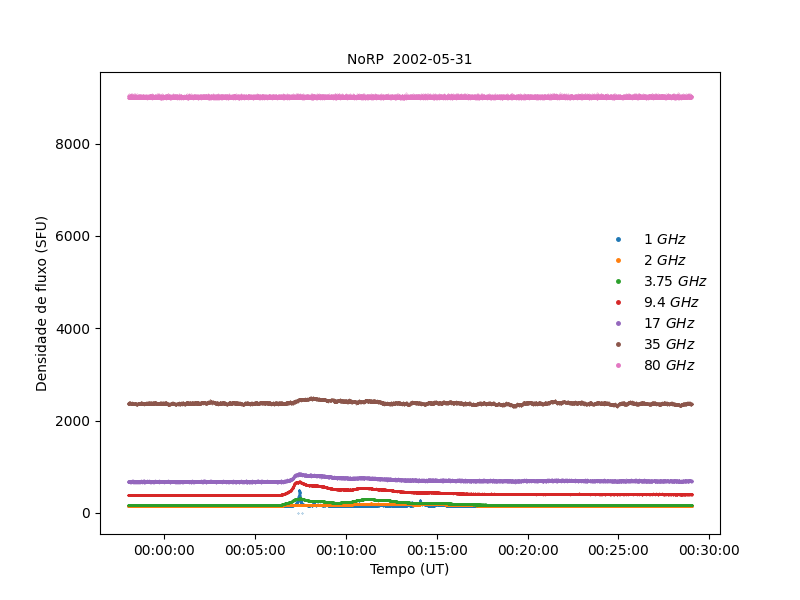

button_press_event: xy=(168, 89) xydata=(11838.00013539585, 51.09567565917996) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)
button_press_event: xy=(242, 90) xydata=(11838.002965273658, 52.912091209775326) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)


In [8]:
# Curvas de luz (perfis temporais) no intervalo de tempo selecionado

lightcurve2 = plt.figure(figsize=(8, 6))
lightcurve2.canvas.mpl_connect('button_press_event', onclick)
lc2=lightcurve2.add_subplot()
plt.title('NoRP  '+norp_rd_obsDay(filename), fontsize=10)
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_1GHzI(filename)[imin:imax], marker=".", linestyle='None', markersize=0.5, label='$1~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_2GHzI(filename)[imin:imax], marker=".", linestyle='None', markersize=0.5, label='$2~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_4GHzI(filename)[imin:imax], marker=".", linestyle='None', markersize=0.5, label='$3.75~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_9GHzI(filename)[imin:imax], marker=".", linestyle='None', markersize=0.5, label='$9.4~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_17GHzI(filename)[imin:imax], marker=".", linestyle='None', markersize=0.5, label='$17~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_35GHzI(filename)[imin:imax], marker=".", linestyle='None', markersize=0.5, label='$35~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_80GHzI(filename)[imin:imax], marker=".", linestyle='None', markersize=0.5, label='$80~GHz$')
lc2.xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
plt.xlabel('Tempo (UT)', fontsize=10)
plt.ylabel('Densidade de fluxo (SFU)', fontsize=10)
plt.legend(loc='best', markerscale=10, fontsize=10, frameon=False)

In [9]:
# Seleção do intervalo de tempo para determinação do background
#
# obs - selecionar um intervalo de tempo pre-flare no qual a densidade de fluxo é aproximadamente constante

tbackmin = posicao[-2]
tbackmax = posicao[-1]
#
pbackmin = num2date(tbackmin[0])
pbackmax = num2date(tbackmax[0])
#
# Determinação dos índices dos tempos inicial (tbackmin) e final (tbackmax)
#
tempos = pd.DataFrame(norp_rd_time(filename))
ibackmin = np.argmin(np.abs(tempos - pbackmin))
ibackmax = np.argmin(np.abs(tempos - pbackmax))

print('tbackmin=',norp_rd_time(filename)[ibackmin].strftime('%H:%M:%S'))
print('tbackmax=',norp_rd_time(filename)[ibackmax].strftime('%H:%M:%S'))

tbackmin= 00:00:11
tbackmax= 00:04:16


In [10]:
# Cálculo do background para cada frequência:
#
# média do fluxo no intervalo de tempo de tbackmin a tbackmax

fiback1GHz=norp_rd_1GHzI(filename)[ibackmin:ibackmax]
fibackavg1GHz = sum(fiback1GHz)/len(fiback1GHz)

fiback2GHz=norp_rd_2GHzI(filename)[ibackmin:ibackmax]
fibackavg2GHz = sum(fiback2GHz)/len(fiback2GHz)

fiback4GHz=norp_rd_4GHzI(filename)[ibackmin:ibackmax]
fibackavg4GHz = sum(fiback4GHz)/len(fiback4GHz)

fiback9GHz=norp_rd_9GHzI(filename)[ibackmin:ibackmax]
fibackavg9GHz = sum(fiback9GHz)/len(fiback9GHz)

fiback17GHz=norp_rd_17GHzI(filename)[ibackmin:ibackmax]
fibackavg17GHz = sum(fiback17GHz)/len(fiback17GHz)

fiback35GHz=norp_rd_35GHzI(filename)[ibackmin:ibackmax]
fibackavg35GHz = sum(fiback35GHz)/len(fiback35GHz)

fiback80GHz=norp_rd_80GHzI(filename)[ibackmin:ibackmax]
fibackavg80GHz = sum(fiback80GHz)/len(fiback80GHz)

print(fibackavg1GHz,fibackavg2GHz,fibackavg4GHz,fibackavg9GHz,fibackavg17GHz,fibackavg35GHz,fibackavg80GHz)

149.36348 154.4508 169.78343 389.9987 681.23645 2379.2468 9010.33


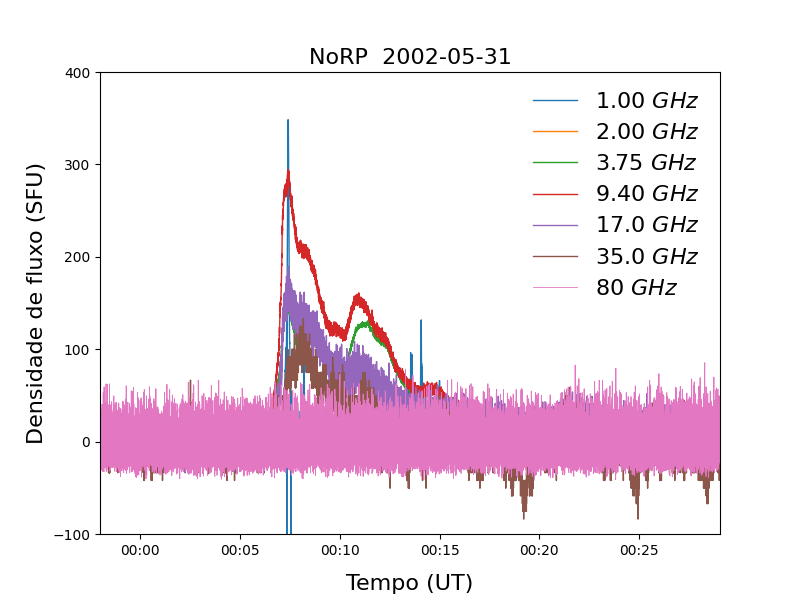

button_press_event: xy=(261, 491) xydata=(11838.004209869978, 359.9567099567099) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)
button_press_event: xy=(353, 445) xydata=(11838.005103653595, 277.3237945315867) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)
button_press_event: xy=(389, 448) xydata=(11838.005230832292, 280.3105264144225) button=1 dblclick=False inaxes=Axes(0.125,0.11;0.775x0.77)


In [11]:
# Curvas de luz (perfis temporais) com background subtraído

lightcurve3 = plt.figure(figsize=(8, 6))
lightcurve3.canvas.mpl_connect('button_press_event', onclick)
lc3=lightcurve3.add_subplot()
plt.title('NoRP  '+norp_rd_obsDay(filename), fontsize=16)
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_1GHzI(filename)[imin:imax]-fibackavg1GHz, linestyle='solid', linewidth=1, label='$1.00~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_2GHzI(filename)[imin:imax]-fibackavg2GHz, linestyle='solid', linewidth=1, label='$2.00~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_4GHzI(filename)[imin:imax]-fibackavg4GHz, linestyle='solid', linewidth=1, label='$3.75~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_9GHzI(filename)[imin:imax]-fibackavg9GHz, linestyle='solid', linewidth=1, label='$9.40~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_17GHzI(filename)[imin:imax]-fibackavg17GHz, linestyle='solid', linewidth=1, label='$17.0~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_35GHzI(filename)[imin:imax]-fibackavg35GHz, linestyle='solid', linewidth=1, label='$35.0~GHz$')
plt.plot (norp_rd_time(filename)[imin:imax],norp_rd_80GHzI(filename)[imin:imax]-fibackavg80GHz, linestyle='solid', linewidth=0.6, label='$80~GHz$')
lc3.xaxis.set_major_formatter(DateFormatter('%H:%M'))
plt.xlabel('Tempo (UT)', labelpad=12, fontsize=16)
plt.ylabel('Densidade de fluxo (SFU)', fontsize=16)
plt.xlim(pmin,pmax)
plt.ylim(-100,400)
plt.legend(loc='best', fontsize=16,frameon=False)
plt.savefig('/content/drive/MyDrive/Bruno//norp_2002_05_31/NoRP '+norp_rd_obsDay(filename), dpi=3600, bbox_inches = 'tight', pad_inches = 0.05)

In [12]:
# Seleção do intervalo de tempo para determinação do espectro
#
# obs - selecionar um intervalo de tempo em torno do máximo da densidade de fluxo (pico observado na curva de luz)

tpeakmin = posicao[-2]
tpeakmax = posicao[-1]
#
ppeakmin = num2date(tpeakmin[0])
ppeakmax = num2date(tpeakmax[0])
#
# Determinação dos índices dos tempos inicial (tpeakmin) e final (tpeakmax)
#
tempos = pd.DataFrame(norp_rd_time(filename))
ipeakmin = np.argmin(np.abs(tempos - ppeakmin))
ipeakmax = np.argmin(np.abs(tempos - ppeakmax))

print('tpeakmin=',norp_rd_time(filename)[ipeakmin].strftime('%H:%M:%S'))
print('tpeakmax=',norp_rd_time(filename)[ipeakmax].strftime('%H:%M:%S'))

tpeakmin= 00:07:20
tpeakmax= 00:07:31


In [13]:
# Cálculo do fluxo com background subtraído para cada frequência:
#
# média do fluxo no intervalo de tempo de tpeakmin a tpeakmax

fipeak1GHz=norp_rd_1GHzI(filename)[ipeakmin:ipeakmax]
fipeakavg1GHz = sum(fipeak1GHz)/len(fipeak1GHz)-fibackavg1GHz

fipeak2GHz=norp_rd_2GHzI(filename)[ipeakmin:ipeakmax]
fipeakavg2GHz = sum(fipeak2GHz)/len(fipeak2GHz)-fibackavg2GHz

fipeak4GHz=norp_rd_4GHzI(filename)[ipeakmin:ipeakmax]
fipeakavg4GHz = sum(fipeak4GHz)/len(fipeak4GHz)-fibackavg4GHz

fipeak9GHz=norp_rd_9GHzI(filename)[ipeakmin:ipeakmax]
fipeakavg9GHz = sum(fipeak9GHz)/len(fipeak9GHz)-fibackavg9GHz

fipeak17GHz=norp_rd_17GHzI(filename)[ipeakmin:ipeakmax]
fipeakavg17GHz = sum(fipeak17GHz)/len(fipeak17GHz)-fibackavg17GHz

fipeak35GHz=norp_rd_35GHzI(filename)[ipeakmin:ipeakmax]
fipeakavg35GHz = sum(fipeak35GHz)/len(fipeak35GHz)-fibackavg35GHz

fipeak80GHz=norp_rd_80GHzI(filename)[ipeakmin:ipeakmax]
fipeakavg80GHz = sum(fipeak80GHz)/len(fipeak80GHz)-fibackavg80GHz

print(fipeakavg1GHz,fipeakavg2GHz,fipeakavg4GHz,fipeakavg9GHz,fipeakavg17GHz,fipeakavg35GHz,fipeakavg80GHz)

200.33485 26.596634 141.69652 281.75168 160.24072 72.83179 -0.5644531


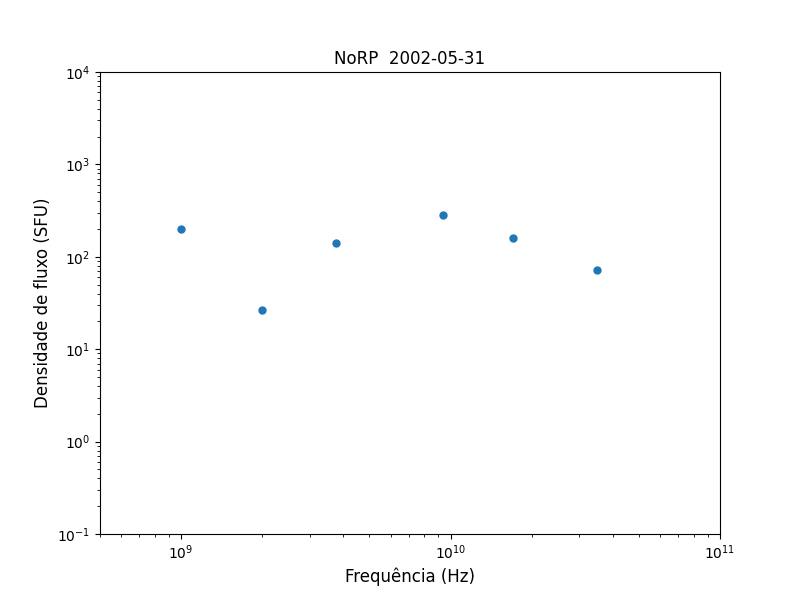

In [14]:
# Espectro: densidade de fluxo (SFU) X frequência (Hz)

flux=[fipeakavg1GHz,fipeakavg2GHz,fipeakavg4GHz,fipeakavg9GHz,fipeakavg17GHz,fipeakavg35GHz,fipeakavg80GHz]
freq = [1e9, 2e9, 3.75e9, 9.4e9, 17e9, 35e9, 80e9]

spectrum = plt.figure(figsize=(8, 6))
spec=spectrum.add_subplot()
plt.title('NoRP  '+norp_rd_obsDay(filename))
plt.plot (freq,flux,marker=".", linestyle='None', markersize=10)
plt.xlabel('Frequência (Hz)', fontsize=12)
plt.ylabel('Densidade de fluxo (SFU)', fontsize=12)
plt.xlim(0.5e9,1e11)
plt.ylim(0.1,10000)
plt.xscale('log')
plt.yscale('log')

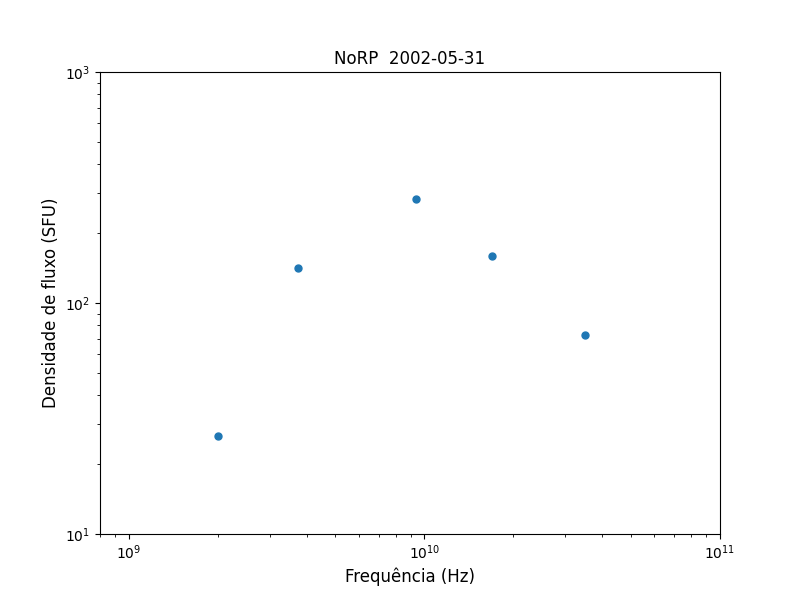

In [15]:
# Excluir frequências (caso necessário):

# - 1 e 2 GHz quando apresentarem contaminação por emissão de plasma (térmica),
# isto é, não seguirem padrão de emissão girossincrotrônica

# - 80 GHz quando não seguir o padrão de emissão girossincrotrônica


# Espectro final: densidade de fluxo (SFU) X frequência (Hz)

flux=[fipeakavg2GHz,fipeakavg4GHz,fipeakavg9GHz,fipeakavg17GHz,fipeakavg35GHz]
freq = [2e9, 3.75e9, 9.4e9, 17e9, 35e9]

spectrum = plt.figure(figsize=(8, 6))
spec=spectrum.add_subplot()
plt.title('NoRP  '+norp_rd_obsDay(filename))
plt.plot (freq,flux,marker=".", linestyle='None', markersize=10)
plt.xlabel('Frequência (Hz)', fontsize=12)
plt.ylabel('Densidade de fluxo (SFU)', fontsize=12)
plt.xlim(0.8e9,1e11)
plt.ylim(10,1000)
plt.xscale('log')
plt.yscale('log')
plt.savefig('NoRP spectrum '+norp_rd_obsDay(filename), dpi=1200, bbox_inches = 'tight', pad_inches = 0.05)

In [16]:
# Arquivo de saída

fluxo=np.column_stack([freq,flux])
np.savetxt('/content/drive/MyDrive/Bruno/norp_2002_05_31/NoRP '+norp_rd_obsDay(filename)+'.dat',fluxo,fmt='%.5E')